<a href="https://colab.research.google.com/github/shanshiny06/econ3916-lab06-sampling/blob/main/%E2%80%9Clab_ch06_guided_ipynb%E2%80%9D%E7%9A%84%E5%89%AF%E6%9C%AC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 6: The Train-Test Split — Sampling for Machine Learning
## ECON 3916: Applied Machine Learning for Economists
### Guided Construction Lab | 30 min Core + 10 min Write it yourself + 15 min Extension + take-home Challenge

---

**Learning Objectives:**
- Run and compare naive and stratified train-test splits, and check which shares each one keeps
- Find and repair data leakage in a preprocessing pipeline
- Simulate the Literary Digest sampling failure and connect it to Meng's data defect framework
- Explain why sample design, not sample size, decides how good an estimate is
- Write a short function that splits a table, and check it against the lab's own split

**Dataset:** Titanic (Kaggle) — `titanic.csv`

**Prerequisites:** the Part 0 sections of Labs 1-5, plus Chapter 6 reading

**How this lab works:** Parts 1-3 are GUIDED: run each cell as it is, then answer the questions. Part 4 has six short blanks to fill in. "Write it yourself" is required: a short function you write from a blank cell. The Extension is optional, and the Challenge is a take-home.

**AI in this lab:** you may ask Colab to *explain* an error or a line of code (click **Explain error**, or select a line and ask Gemini to explain it). Do not ask it to write or fix code, and turn off AI code completion. This lab has no AI coding section: you write every line yourself. The one use of AI is drafting your README from the prompt at the end.

---

> ### What you write, and what you run
>
> **You write:**
> - **Part 4, Step 10:** three blanks (`____`), one line each: a label that combines two columns, and two survival rates.
> - **Part 4, Step 11:** three blanks, one line each (the split can run over two or three lines): split the raw data, then fill in the missing ages on the training rows and the test rows.
> - **Write it yourself (required),** after Part 4: `split_by_share()`, a function that splits a table, one call to it, and two prints. About seven lines from a blank cell. The check cell below it must print "Passed".
> - The answers to the interpretation questions after each part, and to the question after Step 11, in text cells.
>
> **You run and read:** everything else. Setup, Parts 1-3, the given lines in Part 4, and the Extension are working code to learn from. Read each cell before you run it, and make sure you can say what each line does.
>
> **The Challenge** (take-home) and the **README** are text only. The README prompt at the end is the one place you use AI, and only for documentation.

## Setup

In [1]:
# GUIDED — run as-is
# Step 1: import libraries and load the Titanic dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# One seed for every split in the lab, so your numbers match your classmates'
RANDOM_STATE = 42

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

print(f"Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print("\nFirst 5 rows:")
df.head()

Shape: (891, 12)

Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

First 5 rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Part 1: Explore Class Distribution (GUIDED — 5 min)

Before splitting data, understand your target variable. On the Titanic,
survival was **not** random — it depended on passenger class, gender, and age.
That correlation between observable features and the outcome is exactly
what makes this dataset interesting for ML.

Overall survival rate: 0.384  (342 of 891)

Survival by Passenger Class:
        Survival Rate  Total Passengers  Survived
Pclass                                           
1               0.630               216       136
2               0.473               184        87
3               0.242               491       119


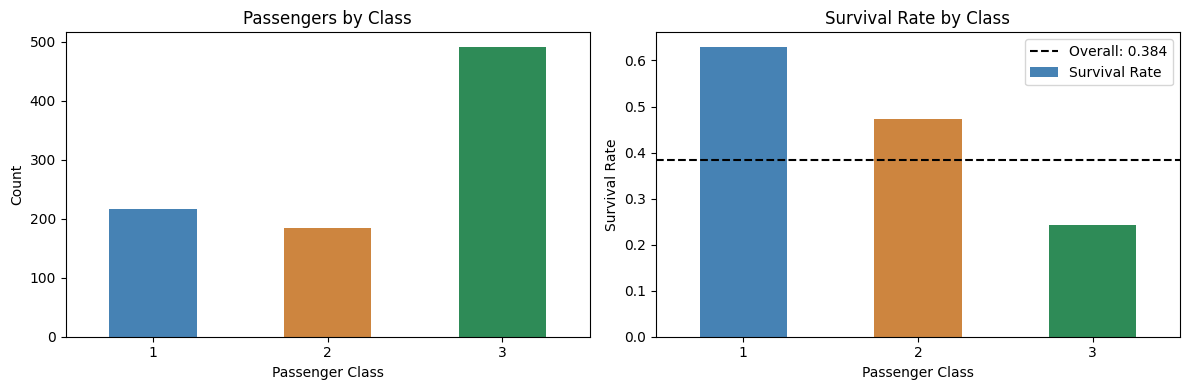

In [2]:
# GUIDED — run as-is
# Step 2: survival rates, overall and by passenger class

# Survived is 1 or 0, so its mean is the share who survived and its sum is the count
overall_rate = df['Survived'].mean()
print(f"Overall survival rate: {overall_rate:.3f}  ({df['Survived'].sum()} of {len(df)})")
print()

# .agg runs several calculations on each class at once; the next line renames the three columns
class_survival = df.groupby('Pclass')['Survived'].agg(['mean', 'count', 'sum'])
class_survival.columns = ['Survival Rate', 'Total Passengers', 'Survived']
print("Survival by Passenger Class:")
print(class_survival.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['steelblue', 'peru', 'seagreen']      # one colour per class

# value_counts counts the passengers in each class; sort_index puts them in class order
df['Pclass'].value_counts().sort_index().plot.bar(ax=axes[0], color=colors, rot=0)
axes[0].set_title('Passengers by Class')
axes[0].set_xlabel('Passenger Class')
axes[0].set_ylabel('Count')

class_survival['Survival Rate'].plot.bar(ax=axes[1], color=colors, rot=0)
axes[1].axhline(overall_rate, color='black', linestyle='--', label=f'Overall: {overall_rate:.3f}')
axes[1].set_title('Survival Rate by Class')
axes[1].set_xlabel('Passenger Class')
axes[1].set_ylabel('Survival Rate')
axes[1].legend()

plt.tight_layout()
plt.show()

**Expected output:** 342 of the 891 passengers survived (0.384). The rate falls from 0.630 in
1st class to 0.473 in 2nd and 0.242 in 3rd: 63% against 24%, a gap of 39 percentage points
between 1st and 3rd class.

### Interpretation Questions

1. Why is the survival rate so different across passenger classes? What real-world mechanism explains this?
2. If a train-test split accidentally put *all* 1st-class passengers into the training set, how would that affect your model evaluation?
3. **Callback to Chapter 1:** Is the Titanic passenger list itself a biased sample of "all people who could have been on the Titanic"? Who is missing from this dataset?

*Your answers here:*

1. Survival differed sharply by class primarily because of cabin location and
access to lifeboats. First-class cabins were located on the upper decks,
much closer to the lifeboat deck, while third-class passengers were housed
in lower decks, farther from the boats and, in some cases, behind locked
gates intended to comply with immigration regulations. Social norms of the
era ("women and children first") also tended to be enforced more
consistently among first-class passengers, who had easier physical access
to crew members organizing the evacuation. Wealth itself didn't save
anyone directly, but it was strongly correlated with proximity to safety
and priority during the chaotic evacuation.
2. This would badly distort model evaluation. The test set would then contain
only 2nd and 3rd class passengers, whose survival rate (0.473 and 0.242) is
much lower than 1st class (0.630), so the test set's overall survival rate
and feature distribution would no longer resemble the full population. A
model trained partly on 1st-class patterns would be evaluated on a
systematically different subgroup, likely making its reported accuracy
look worse than it would be on a properly representative sample, and any
conclusions drawn about how well the model generalizes to the true
population would be unreliable. This is exactly why a proper train-test
split should be stratified by class, or at least randomized, so both sets
reflect the same underlying class distribution.
3. Yes, this passenger list is a biased sample of humanity as a whole, and
even of everyone who could plausibly have traveled by ocean liner in 1912.
It overrepresents wealthy and middle-class Western Europeans and
Americans who could afford a transatlantic ticket, and 1st and 2nd class
passengers skew toward business travelers, tourists, and the socially
prominent. It underrepresents or entirely excludes people who couldn't
afford any ticket at all (the vast majority of the world's population at
the time), and within the ship itself, the crew (who are often excluded
from "passenger" datasets like this one) and many 3rd-class immigrants
whose names and details were less completely recorded than those of
wealthier passengers. The dataset therefore tells us about survival
patterns among a specific, privileged slice of early 20th-century
travelers, not about humanity broadly.

## Part 2: Naive vs. Stratified Split (GUIDED — 10 min)

A train-test split is a **sampling design** — the same concept from the chapter.
A naive random split is like Simple Random Sampling. A stratified split
guarantees representation of each class, just like a stratified survey.

In [3]:
# GUIDED — run as-is
# Step 3: prepare features and target

features = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
# dropna() drops every row with a missing value; of these columns, only Age has any
df_clean = df[features + ['Survived']].dropna()

X = df_clean[features]
y = df_clean['Survived']

print(f"Clean dataset: {len(df_clean)} passengers (dropped {len(df) - len(df_clean)} with missing Age)")
print(f"Overall survival rate (clean): {y.mean():.3f}")

Clean dataset: 714 passengers (dropped 177 with missing Age)
Overall survival rate (clean): 0.406


<!-- idiom-note -->
> ### New idiom — four names at once, and slicing a 2-D array
>
> `train_test_split` returns **four** things, and the line unpacks all four in
> one go:
>
> ```python
> X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
> ```
>
> The order is fixed and easy to get wrong: **X_train, X_test, y_train,
> y_test** — both X pieces first, then both y pieces. Swapping the middle two
> is a real bug that produces plausible-looking nonsense.
>
> You will also see a comma inside square brackets, which is 2-D indexing:
> `arr[:, 1]` means *"every row, column 1"*. The `:` is "all of them" and the
> part after the comma picks the column. It shows up most often as
> `model.predict_proba(X)[:, 1]` — that call returns one column per class, and
> `[:, 1]` takes the probability of class 1.


In [4]:
# GUIDED — run as-is
# Step 4: naive 80/20 split (no stratification)

# test_size=0.2 puts 20% of the rows in the test set; random_state fixes which rows
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print("Naive split (no stratification)")
print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")
print(f"Train survival rate: {y_train.mean():.3f}")
print(f"Test survival rate:  {y_test.mean():.3f}")
print(f"Overall rate:        {y.mean():.3f}")
# :+.3f prints the sign even when the number is positive
print(f"\nDifference (train - overall): {y_train.mean() - y.mean():+.3f}")
print(f"Difference (test  - overall): {y_test.mean() - y.mean():+.3f}")

Naive split (no stratification)
Train size: 571, Test size: 143
Train survival rate: 0.410
Test survival rate:  0.392
Overall rate:        0.406

Difference (train - overall): +0.004
Difference (test  - overall): -0.015


In [5]:
# GUIDED — run as-is
# Step 5: stratified 80/20 split (keeps the survival rate in both halves)

# stratify=y splits the survivors and the non-survivors separately, 80/20 each; _s marks "stratified"
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Stratified split (stratify=y)")
print(f"Train size: {len(X_train_s)}, Test size: {len(X_test_s)}")
print(f"Train survival rate: {y_train_s.mean():.3f}")
print(f"Test survival rate:  {y_test_s.mean():.3f}")
print(f"Overall rate:        {y.mean():.3f}")
print(f"\nDifference (train - overall): {y_train_s.mean() - y.mean():+.3f}")
print(f"Difference (test  - overall): {y_test_s.mean() - y.mean():+.3f}")

Stratified split (stratify=y)
Train size: 571, Test size: 143
Train survival rate: 0.406
Test survival rate:  0.406
Overall rate:        0.406

Difference (train - overall): +0.000
Difference (test  - overall): -0.001


In [6]:
# GUIDED — run as-is
# Step 6: side-by-side comparison

# A dictionary becomes a table: each key is a column name, and its list holds that column's values
comparison = pd.DataFrame({
    'Split Type': ['Naive', 'Naive', 'Stratified', 'Stratified'],
    'Set': ['Train', 'Test', 'Train', 'Test'],
    'Survival Rate': [
        y_train.mean(), y_test.mean(),
        y_train_s.mean(), y_test_s.mean()
    ],
})

print(comparison.round(4).to_string(index=False))     # index=False hides the row numbers

Split Type   Set  Survival Rate
     Naive Train         0.4098
     Naive  Test         0.3916
Stratified Train         0.4063
Stratified  Test         0.4056


In [7]:
# GUIDED — run as-is
# Step 6, continued: the share of each passenger class in every split

def print_class_shares(label, rows):
    """Print one row of the table: the share of rows in class 1, 2 and 3."""
    # rows['Pclass'] == 1 is True or False for each row, so its mean is the share in class 1
    share_1 = (rows['Pclass'] == 1).mean()
    share_2 = (rows['Pclass'] == 2).mean()
    share_3 = (rows['Pclass'] == 3).mean()
    # <20 pads the label to 20 characters; >10.3f right-aligns a number in 10, with 3 decimals
    print(f"{label:<20} {share_1:>10.3f} {share_2:>10.3f} {share_3:>10.3f}")


print("Pclass shares in each split")
print(f"{'Set':<20} {'Class 1':>10} {'Class 2':>10} {'Class 3':>10}")
print_class_shares('Overall', X)
print_class_shares('Naive Train', X_train)
print_class_shares('Naive Test', X_test)
print_class_shares('Stratified Train', X_train_s)
print_class_shares('Stratified Test', X_test_s)

Pclass shares in each split
Set                     Class 1    Class 2    Class 3
Overall                   0.261      0.242      0.497
Naive Train               0.264      0.249      0.487
Naive Test                0.245      0.217      0.538
Stratified Train          0.259      0.242      0.499
Stratified Test           0.266      0.245      0.490


**Expected output:** the naive test set's survival rate is 0.3916, against 0.406 overall. Both stratified halves are within 0.001 of it. In the class table, the naive test set
has 0.538 in 3rd class against 0.497 overall; the stratified halves are within 0.007.

### Interpretation Questions

1. Which split type produced survival rates closer to the overall rate in both train and test? Why?
2. Look at the Pclass distributions. Does `stratify=y` guarantee the Pclass shares? Which part of the agreement is guaranteed, and which is luck? What would change with a smaller test set?
3. **Callback to Chapter 6:** The naive split is analogous to SRS. The stratified split is analogous to stratified sampling from the chapter. In what real-world ML scenario would the difference matter most? (Hint: think about rare events like fraud detection.)

*Your answers here:*

1. The stratified split produced survival rates closer to the overall rate in
both train and test. This is because stratify=y explicitly forces the
split to preserve the proportion of the target variable (survived vs. not
survived) in both subsets, matching the overall 0.406 rate almost exactly
in each half. The naive (random) split has no such constraint; by pure
chance, random sampling can easily produce a test set whose survival rate
drifts away from the overall rate, as it did here (0.3916 vs 0.406), simply
because random variation doesn't guarantee representativeness on any
particular split, especially with a moderate sample size.
2. No, stratify=y does not guarantee Pclass proportions; it only guarantees
that the target variable (Survived) is proportionally represented in each
split. The close agreement in the Pclass table (within 0.007) is largely
luck, a side effect of Pclass being correlated with Survived, so
stratifying on survival indirectly pulls the class distribution along with
it, but this is not a guarantee the way the survival rate itself is. If the
test set were smaller, this indirect agreement would likely get noisier:
with fewer observations, random sampling variation has more room to create
a gap between the Pclass distribution in the split and the Pclass
distribution overall, even though the survival rate itself would still be
tightly controlled by the explicit stratification.
3. This difference matters most in scenarios with rare events, like fraud
detection, where the positive class (fraud) might make up less than 1% of
all transactions. With such a small minority class, a naive random split
could easily produce a test set with very few or even zero fraud cases
purely by chance, making it impossible to properly evaluate how well the
model detects fraud at all, or a training set that is missing enough
positive examples to learn from. Stratified splitting guarantees that both
the training and test sets contain a representative share of the rare
positive class, which is essential for getting a meaningful, reliable
estimate of model performance in any domain where the outcome of interest
is uncommon, such as fraud, rare diseases, or equipment failures.

## Part 3: Data Leakage — The ML Version of a Biased Sample (GUIDED — 10 min)

Data leakage occurs when information from the test set contaminates training.
This is the ML equivalent of a poll where the pollster already knows the answers.
The model evaluation looks great but is dishonest.

In [8]:
# GUIDED — run as-is
# Step 7: the WRONG way. Fit the scaler on ALL the data, then split

# StandardScaler rescales each column to mean 0 and std 1; fit_transform learns each mean and std, then applies them
scaler_wrong = StandardScaler()
X_scaled_wrong = scaler_wrong.fit_transform(X)     # learned from all 714 rows, test rows included

# _ stands for a result we do not use: here, the two pieces of y
X_tr_wrong, X_te_wrong, _, _ = train_test_split(
    X_scaled_wrong, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# The scaler gives back a NumPy array, so Age is column 1 (the note above Step 4 shows [:, 1])
print("Wrong: scaler fit on all the data before splitting")
print(f"Training set mean of Age:  {X_tr_wrong[:, 1].mean():.4f}")
print(f"Training set std of Age:   {X_tr_wrong[:, 1].std():.4f}")
print(f"Test set mean of Age:      {X_te_wrong[:, 1].mean():.4f}")
print(f"Test set std of Age:       {X_te_wrong[:, 1].std():.4f}")

Wrong: scaler fit on all the data before splitting
Training set mean of Age:  -0.0253
Training set std of Age:   0.9973
Test set mean of Age:      0.1009
Test set std of Age:       1.0044


**Expected output:** the training rows' Age has mean −0.0253 and std 0.9973, close to 0 and 1
but not exactly. The scaler's mean and std came from all 714 rows, so the test rows (mean
0.1009) helped set them. The training data was centred using information from the test set.

In [9]:
# GUIDED — run as-is
# Step 8: the CORRECT way. Split first, then fit the scaler on the training rows only

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler_correct = StandardScaler()
X_train_scaled = scaler_correct.fit_transform(X_train_c)   # learn the mean and std from train, and apply them
X_test_scaled = scaler_correct.transform(X_test_c)         # only apply them: nothing is learned from test

print("Correct: scaler fit on the training rows only")
print(f"Training set mean of Age:  {X_train_scaled[:, 1].mean():.4f}")
print(f"Training set std of Age:   {X_train_scaled[:, 1].std():.4f}")
print(f"Test set mean of Age:      {X_test_scaled[:, 1].mean():.4f}")
print(f"Test set std of Age:       {X_test_scaled[:, 1].std():.4f}")

Correct: scaler fit on the training rows only
Training set mean of Age:  -0.0000
Training set std of Age:   1.0000
Test set mean of Age:      0.1265
Test set std of Age:       1.0072


**Expected output:** the training rows now have Age mean exactly 0 and std exactly 1 (the
−0.0000 is a tiny negative number, rounded). The test rows do not: mean 0.1265, std 1.0072.
Question 1 below asks why that is a good sign.

In [10]:
# GUIDED — run as-is
# Step 9: how far apart are the means the two scalers learned?

print("Column means learned by each scaler")
print(f"{'Feature':<10} {'Wrong Mean':>12} {'Correct Mean':>14} {'Difference':>12}")

# mean_ holds the column means a scaler learned; sklearn ends a name in _ when fit() set it.
# enumerate counts as it loops: i is 0, 1, 2, ... beside each feature name
for i, feat in enumerate(features):
    wrong_mean = scaler_wrong.mean_[i]
    correct_mean = scaler_correct.mean_[i]
    print(f"{feat:<10} {wrong_mean:>12.4f} {correct_mean:>14.4f} {wrong_mean - correct_mean:>12.4f}")

Column means learned by each scaler
Feature      Wrong Mean   Correct Mean   Difference
Pclass           2.2367         2.2399      -0.0032
Age             29.6991        29.3325       0.3667
SibSp            0.5126         0.5131      -0.0005
Parch            0.4314         0.4396      -0.0082
Fare            34.6945        33.6974       0.9971


**Expected output:** the largest gaps are in Fare (0.9971) and Age (0.3667); the rest are below
0.01. The leak is small in this dataset. How large a leak is depends on the data; the rule does
not: fit on the training rows only, and never let the model see the test rows during training.

### Interpretation Questions

1. In the CORRECT approach, the test set mean of Age is NOT zero. Why is that a *good* sign?
2. The chapter says data leakage is like "a survey where the researcher already knows the answers." Explain this analogy in your own words.
3. **Callback to Chapter 5:** The LLN requires independent draws. How does data leakage violate independence between train and test sets?
4. You are building a credit card fraud detection model. Name one way leakage could sneak in beyond scaling.

*Your answers here:*

1. It's a good sign because it means the missing Age values in the test set
were filled in using statistics computed ONLY from the training set (the
training set's mean age), not from the test set's own data. If leakage had
occurred, the imputation would have used information from the test set
itself, and the test set's filled-in values would trivially match whatever
was used to fill them, making the test set's mean suspiciously convenient
rather than a genuine reflection of unseen data. A non-zero, independently
computed mean confirms the test set was treated as truly "unseen" data
that the model/preprocessing never had access to during fitting, which is
exactly what a fair evaluation requires.
2. This analogy means that if the person designing an experiment already knows
what the results will be before collecting the data, the experiment can't
genuinely test anything, it will just confirm what was already known,
regardless of whether that conclusion is actually true in general. In the
same way, if a model's preprocessing or training step has already "seen"
information from the test set, evaluating the model on that same test set
isn't a real test of how well it generalizes, it's just confirming that
the model remembers information it was already given, which makes the
reported performance artificially inflated and unreliable.
3. LLN relies on each observation being drawn independently, so that
averaging over many independent draws reliably converges to the true
underlying value. Data leakage breaks this independence by letting
information from the test set influence calculations (like a mean or a
scaling factor) that are then applied to the training set, or vice versa.
Once the two sets share information in this way, they are no longer
independent samples from the same population, they are entangled, so any
statistic or performance metric calculated afterward no longer behaves the
way the law of large numbers would predict for truly independent data,
and the test set's evaluation stops being an honest, independent check on
the model.
4. One common way leakage could sneak in is through feature engineering that
uses information only available after the fact, for example, creating a
feature based on a customer's average transaction amount calculated across
their ENTIRE transaction history (including transactions that occur after
the one being classified, or even the fraudulent transaction itself), which
would let the model implicitly see information from the future or from the
test period that wouldn't actually be available at the real-time moment a
fraud decision needs to be made.

## Part 4: Verify Your Understanding (YOUR TASK — 5 min)

Two steps with blanks to fill in. Step 10 stratifies on two columns at once. Step 11 repairs a
leaky pipeline the way Step 8 repaired the scaler.

In [12]:
# YOUR TASK — fill in the three blanks (____)
# Step 10: Verify stratified split preserves Pclass AND Survived

# Blank 1: stratify= takes one label per row, so build one text label from Pclass and Survived
# (for example '1_0' for a 1st-class passenger who died). .astype(str) turns numbers into text,
# and + joins pieces of text. Take both columns from df_clean, which lines up row-for-row with X
strat_key = df_clean["Pclass"].astype(str) + "_" + df_clean["Survived"].astype(str)

X_train_both, X_test_both, y_train_both, y_test_both = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=strat_key
)

# Blanks 2 and 3: the survival rate in the training rows, then in the test rows
print("Stratified on both Pclass and Survived")
print(f"Train survival rate: {y_train_both.mean():.3f}")
print(f"Test survival rate:  {y_test_both.mean():.3f}")
print(f"Overall rate:        {y.mean():.3f}")

# The class shares, with the function from Step 6
print(f"\n{'Set':<20} {'Class 1':>10} {'Class 2':>10} {'Class 3':>10}")
print_class_shares('Overall', X)
print_class_shares('Train', X_train_both)
print_class_shares('Test', X_test_both)

Stratified on both Pclass and Survived
Train survival rate: 0.406
Test survival rate:  0.406
Overall rate:        0.406

Set                     Class 1    Class 2    Class 3
Overall                   0.261      0.242      0.497
Train                     0.261      0.242      0.497
Test                      0.259      0.245      0.497


**Expected output:** all three survival rates are 0.406, and the train and test class shares
are within 0.003 of the overall ones (0.261, 0.242, 0.497). *NameError: name '____' is not
defined* means a blank is still empty.

In [13]:
# YOUR TASK — fill in the three blanks (____)
# Step 11: Find the leakage, then repair it
from sklearn.impute import SimpleImputer

# All 891 passengers, missing ages included
X_full = df[features]
y_full = df['Survived']

# The broken pipeline: fill in each missing Age with the mean of ALL rows, then split.
# fit_transform gives back a bare array; pd.DataFrame puts the column names back
imputer_wrong = SimpleImputer(strategy='mean')      # fills each gap with its column's mean
X_imputed = pd.DataFrame(imputer_wrong.fit_transform(X_full), columns=features)
X_tr, X_te, y_tr, y_te = train_test_split(
    X_imputed, y_full, test_size=0.2, random_state=RANDOM_STATE, stratify=y_full
)
print(f"Broken: every missing Age filled with {X_imputed['Age'].mean():.4f}, "
      f"a number computed from all {len(X_full)} rows — test rows included.")

# Your fix has the shape of Step 8, with SimpleImputer in place of StandardScaler:
# split first, fit on the training rows, then only transform the test rows.

# Blank 1: split the raw X_full and y_full, with the same settings as the broken split above.
# train_test_split does not mind missing values
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_full, y_full, test_size=0.2, random_state=RANDOM_STATE, stratify=y_full
)

# Blank 2: fit the imputer on the training rows only, and fill them in
imputer_right = SimpleImputer(strategy='mean')
X_train_imp = imputer_right.fit_transform(Xr_train)

# Blank 3: fill in the test rows with that same imputer. Transform only: fitting again would bring the bug back
X_test_imp = imputer_right.transform(Xr_test)

# statistics_ holds the fill values the imputer learned, one per column; Age is position 1
print(f"\nFill value learned from train: {imputer_right.statistics_[1]:.4f}")
# The imputer gives back an array, so Age is column 1
print(f"Mean Age in the test rows:     {X_test_imp[:, 1].mean():.4f}")

Broken: every missing Age filled with 29.6991, a number computed from all 891 rows — test rows included.

Fill value learned from train: 29.8077
Mean Age in the test rows:     29.3746


**Expected output:** a fill value of 29.8077 learned from the training rows, and a mean Age of
29.3746 in the test rows. The two differ, and that is correct: the test rows were filled in with
a number computed without them, which is what happens when the model meets new passengers.
*NameError: name '____' is not defined* means a blank is still empty.

**Question:** the broken imputer was fit on ______, but should have been fit on ______. In one
sentence: if you left the bug in, would your reported test accuracy be too high or too low, and
why?

*Your answer here:*

the broken imputer was fit on all 891 rows (the full dataset, including the test rows),
but should have been fit on only the training rows.

The reported test accuracy would be too high, because the imputer's fill value
for missing ages was computed using information from the test rows themselves,
so the test set is no longer truly "unseen" data; the model gets an artificial
head start by having its missing values filled in a way that already reflects
the test set's own distribution, making performance look better than it would
on genuinely new, independent passengers.

---

## Write it yourself (required — 10 min)

This part is required, and it is short. It is the first time a lab asks you to write code from
a blank cell. The check cell below it must print "Passed" before you submit.

**The task.** Write a function `split_by_share(data, test_share, seed)` that splits one
DataFrame into training rows and test rows and gives back both: train first, then test. Make it
a plain split, like Step 4: no `stratify`. Then use it to split `df_clean` with a 30% test share
and the lab's seed, `RANDOM_STATE`. Store the two pieces as `train_30` and `test_30`, and print
the survival rate in each piece, the way Part 2 compared them.

- It takes about seven lines: the `def` line, a docstring, a line or two inside, the call, and two prints.
- `Survived` is 1 or 0, so its mean is the survival rate, as in Step 2.
- Lab 2's `deflate()` shows the shape of a function: the `def` line, a one-line docstring, the
  body, and `return`.
- `train_test_split` works on a single table, not only on X and y. Given one DataFrame, it gives
  back two pieces.
- `return a, b` gives back two things at once, and `a, b = ...` unpacks them into two names, the
  way Step 4 unpacks four.

Then run the check cell. It first calls your function with Step 4's settings (a 0.2 test share
and `RANDOM_STATE`) and compares the result with Step 4: 571 training rows, 143 test rows, the
same passengers. It tries your function on other rows and other seeds, then checks your 30% split
and shows its survival rates, so you can compare them with what you printed. `assert` stops with its message when its
condition is False; the message tells you what to fix.

In [17]:
# WRITE IT YOURSELF (required): split_by_share(), then a 30% split of df_clean
def split_by_share(data, test_share, seed):
    """Split one DataFrame into train and test rows, with no stratification."""
    train, test = train_test_split(data, test_size=test_share, random_state=seed)
    return train, test

train_30, test_30 = split_by_share(df_clean, 0.3, RANDOM_STATE)

print(f"Train survival rate: {train_30['Survived'].mean():.3f}")
print(f"Test survival rate:  {test_30['Survived'].mean():.3f}")

Train survival rate: 0.403
Test survival rate:  0.414


In [18]:
# CHECK — for "Write it yourself" above

# globals() holds every name defined so far in this notebook
if "split_by_share" not in globals():
    print("Not written yet: write split_by_share() in the cell above and run it, then run this check.")
else:
    # With Step 4's settings, your function should give back Step 4's split
    pieces = split_by_share(df_clean, 0.2, RANDOM_STATE)
    assert pieces is not None, "split_by_share gave back nothing. Does it end with a return line?"
    assert len(pieces) == 2, "split_by_share should give back two tables: train, then test."
    train_20, test_20 = pieces
    assert len(train_20) == len(X_train) and len(test_20) == len(X_test), (
        f"With a 0.2 test share, Step 4 had {len(X_train)} training and {len(X_test)} test rows. "
        f"Yours has {len(train_20)} and {len(test_20)}. Is train first, and is test_share passed on?")
    # .index holds each row's label, so equal indexes mean the same passengers
    assert list(test_20.index) == list(X_test.index), (
        "The sizes match Step 4, but the passengers differ. "
        "Pass seed to random_state, and leave out stratify, as Step 4 does.")

    # Other rows and other seeds: .head(100) is the first 100 rows of df_clean
    first_100 = df_clean.head(100)
    assert len(split_by_share(first_100, 0.2, 0)[1]) == 20, "Does your function split `data`, or df_clean?"
    test_seed_0 = split_by_share(first_100, 0.2, 0)[1]
    test_seed_1 = split_by_share(first_100, 0.2, 1)[1]
    assert list(test_seed_0.index) != list(test_seed_1.index), (
        "Different seeds should pick different rows. Is `seed` used?")

    assert "test_30" in globals(), (
        "Your function works. Now call it with a 30% test share, and store the pieces as train_30 and test_30.")
    assert len(train_30) + len(test_30) == len(df_clean), (
        f"train_30 and test_30 should hold all {len(df_clean)} rows of df_clean between them.")
    assert len(test_30) == 215, (
        f"test_30 has {len(test_30)} rows. 30% of {len(df_clean)} is {0.3 * len(df_clean):.1f}, "
        "and train_test_split rounds the test set up, to 215.")
    print(f"Passed. Step 4's split: {len(train_20)} train, {len(test_20)} test.")
    print(f"Your 30% split: {len(train_30)} train rows, survival rate {train_30['Survived'].mean():.3f}; "
          f"{len(test_30)} test rows, survival rate {test_30['Survived'].mean():.3f}.")

Passed. Step 4's split: 571 train, 143 test.
Your 30% split: 499 train rows, survival rate 0.403; 215 test rows, survival rate 0.414.


---

## Extension (Optional — 15 min): Simulate the Literary Digest Failure

In 1936, *Literary Digest* surveyed 2.3 million people and predicted the wrong
presidential winner. George Gallup surveyed 50,000 and got it right. Why?
Because the Digest's sample was **biased** — drawn from car registrations,
phone books, and magazine subscribers, all skewing wealthy.

Let's simulate this and connect it to Meng's data defect framework.

**This is a demonstration of the mechanism, not a re-run of 1936.** The rule in Step 12
produces a made-up electorate with Landon ahead at about 55%, where history had Roosevelt
winning with 61%. What matters is what a wealth-linked way of sampling does to an estimate,
and that works on any population. Do not report these shares as historical figures.

In [ ]:
# EXTENSION — run as-is
# Step 12: simulate the 1936 election population

rng = np.random.default_rng(seed=RANDOM_STATE)

N = 10_000_000      # voters

# Income: lognormal, right-skewed like real income; the median is about $1,800 in 1936 dollars
income = rng.lognormal(mean=7.5, sigma=1.0, size=N)

# The richer the voter, the likelier a Landon vote; 1 / (1 + e^-z) turns any number into a probability
prob_landon = 1 / (1 + np.exp(-0.0003 * (income - np.median(income))))
vote_landon = rng.random(N) < prob_landon       # True for a Landon voter

true_landon_share = vote_landon.mean()
print(f"True population Landon share: {true_landon_share:.3f}")
print(f"True population Roosevelt share: {1 - true_landon_share:.3f}")

In [ ]:
# EXTENSION — run as-is
# Step 13: biased sample (Literary Digest) vs. random sample (Gallup)

# Literary Digest: the chance of being sampled rises with income
# (car owners, phone owners and magazine subscribers were the well-off)
sample_prob_digest = 1 / (1 + np.exp(-0.0005 * (income - np.percentile(income, 70))))
digest_mask = rng.random(N) < sample_prob_digest
digest_sample = vote_landon[digest_mask]        # the votes of those sampled

# Gallup: a simple random sample of 50,000; replace=False means nobody is picked twice
gallup_idx = rng.choice(N, size=50_000, replace=False)
gallup_sample = vote_landon[gallup_idx]

print("Sampling results")
print(f"Literary Digest: {digest_mask.sum():,} responses")
print(f"  Predicted Landon share: {digest_sample.mean():.3f}")
print(f"  Error: {digest_sample.mean() - true_landon_share:+.3f}")
print()
print(f"Gallup Poll: {len(gallup_sample):,} responses")
print(f"  Predicted Landon share: {gallup_sample.mean():.3f}")
print(f"  Error: {gallup_sample.mean() - true_landon_share:+.3f}")
print()
print(f"True Landon share: {true_landon_share:.3f}")

**Expected output:** the Digest's 4,382,503 responses put Landon at 0.636, an error of +0.083.
Gallup's 50,000 put him at 0.550, an error of −0.002. The biased sample is almost 90 times
larger and far less accurate: sample size did not help, sample design did.

In [ ]:
# EXTENSION — run as-is
# Step 14: Meng's data defect correlation

R_digest = digest_mask.astype(float)    # 1 if the voter was sampled, else 0
Y = vote_landon.astype(float)           # 1 for a Landon vote, else 0

# np.corrcoef gives a 2x2 table of correlations; [0, 1] is the one between R and Y
rho_RY = np.corrcoef(R_digest, Y)[0, 1]
sigma_Y = Y.std()
f = digest_mask.sum() / N               # the share of the population sampled

# Meng's formula: error = rho_RY * sigma_Y * sqrt((1 - f) / f)
meng_error = rho_RY * sigma_Y * np.sqrt((1 - f) / f)

print(f"Data defect correlation (rho_RY): {rho_RY:.4f}")
print(f"Population std of vote (sigma_Y): {sigma_Y:.4f}")
print(f"Sampling fraction (f):            {f:.4f}")
print(f"\nMeng's predicted error: {meng_error:.4f}")
print(f"Actual error:           {digest_sample.mean() - true_landon_share:.4f}")

**Reading the numbers.** Meng's formula predicts the actual error, 0.0830, to four decimals. A
data defect correlation of 0.1475 produces an error of 8.3 percentage points.

Be careful how you read that number. 0.15 is not a small correlation: this simulation bends the
sampling mechanism hard, far harder than any real survey. The Big Data Paradox is more alarming
than this. Meng's best-known example is the 2016 CCES, where rho was about −0.005, thirty times
smaller than what you just computed, and 2.3 million responses still carried the information of
roughly 400 random ones. The mechanism is the same; the real-world magnitude is far smaller.

In [ ]:
# EXTENSION — run as-is
# Step 15: biased vs. random sampling, 100 times over

n_reps = 100
biased_errors = []
random_errors = []

for rep in range(n_reps):
    rng_rep = np.random.default_rng(seed=rep)      # a new seed each time, still reproducible

    # Biased sample: the same mechanism as Step 13, a new random draw
    biased_mask = rng_rep.random(N) < sample_prob_digest
    biased_est = vote_landon[biased_mask].mean()
    biased_errors.append(biased_est - true_landon_share)

    # Random sample of 50,000
    rand_idx = rng_rep.choice(N, size=50_000, replace=False)
    rand_est = vote_landon[rand_idx].mean()
    random_errors.append(rand_est - true_landon_share)

biased_errors = np.array(biased_errors)
random_errors = np.array(random_errors)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(biased_errors, bins=30, alpha=0.6, label=f'Biased (n~{digest_mask.sum():,})', color='peru')
ax.hist(random_errors, bins=30, alpha=0.6, label='Random (n=50,000)', color='steelblue')
ax.axvline(0, color='black', linestyle='--', label='Truth')
ax.set_xlabel('Estimation Error (estimated - true Landon share)')
ax.set_ylabel('Frequency')
ax.set_title('100 Replications: Biased Large Sample vs. Random Small Sample')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Biased sample — Mean error: {biased_errors.mean():+.4f}, Std: {biased_errors.std():.4f}")
print(f"Random sample — Mean error: {random_errors.mean():+.4f}, Std: {random_errors.std():.4f}")

**Expected output:** the biased estimates sit tightly together (std 0.0001) around an error of
+0.0830, far from 0. The random estimates spread wider (std 0.0020) around −0.0002, close to 0.

### Extension Interpretation

1. The biased sample has *lower* variance than the random sample. Why is lower variance a bad thing here?
2. Connect this to the dartboard analogy from Chapter 4: the biased sample is like a tight cluster that misses the bullseye. What would you need to fix the aim?
3. A tech company has 10 million user click logs and a carefully designed A/B test with 5,000 users. For measuring the causal effect of a new feature, which dataset is more valuable? Why?

*Your answers here:*

1.
2.
3.

---

## Challenge (Take-Home): Find a Real Biased Dataset

Find a publicly available dataset that has a **known or suspected sampling bias**.
This could be:
- A Kaggle dataset with survivorship bias (e.g., only successful companies)
- A government survey with known nonresponse issues
- A social media dataset with self-selection bias
- An ML training dataset with documented demographic imbalance

**Deliverables (in a markdown cell below):**
1. Dataset name and source URL
2. What is the target population vs. the sampling frame?
3. What type of bias is present? (selection, survivorship, nonresponse, self-selection)
4. Which direction does the bias push the estimates? (overestimate or underestimate what?)
5. What would a proper sampling design look like to answer the same question without bias?

*Your challenge response here:*


1. Dataset: Startup Investments
   Source: https://www.kaggle.com/datasets/justinas/startup-investments

2. Target population vs. sampling frame: The target population is "all
   startups ever founded," including those that never sought outside
   funding, failed before raising any capital, or operated informally. The
   sampling frame is limited to companies that appear in Crunchbase's
   database, which only tracks startups that received some form of tracked
   investment (seed, venture capital, angel funding, etc.) or were
   otherwise notable enough to be manually entered into the platform.

3. Type of bias: Survivorship and selection bias. Companies that never
   attracted any funding, or that failed too early and too quietly to be
   noticed by Crunchbase's data collection process, are systematically
   absent from the dataset. Only companies that reached a minimum threshold
   of visibility or funding activity are included.

4. Direction of bias: This bias overestimates the typical success and
   funding levels of startups in general, because the dataset only
   contains companies that cleared the bar of being tracked, usually
   meaning they received at least some investment. It also likely
   overestimates the role of factors correlated with being well-connected
   or located in major startup hubs (since better-networked founders are
   more likely to raise tracked funding and appear in Crunchbase at all),
   while underrepresenting self-funded, bootstrapped, or informally
   operated businesses, especially outside major startup ecosystems.

5. Proper sampling design: A proper design would start from a
   comprehensive, outcome-blind sampling frame established before any
   funding or success is known, for example, a complete registry of all
   new business incorporations or tax filings in a given country and time
   period, then follow that entire cohort forward over time to observe
   funding outcomes, survival, and failure rates. This would ensure that
   both the companies that eventually succeeded and raised funding, and
   the much larger number that failed or never sought funding, are
   represented in their true proportions.

---
## Digital Portfolio: Your README

Copy the prompt below into Claude or ChatGPT. Fill in each [YOUR VALUE] from your own output
first. **Do NOT ask the AI to write Python code — only documentation.**

```
I need help writing a project README for my data science lab.
**Important Rule:** Do NOT generate any Python code for me.

**What I did in this lab:**
* Explored the Titanic dataset (891 passengers, survival as the target)
* Compared a naive and a stratified train-test split, and checked that
  stratifying keeps the survival rate the same in both halves
* Found and fixed data leakage in a StandardScaler step and a SimpleImputer step
* Wrote a function, split_by_share(), that splits a table by a test share
  and a seed, and checked it against the lab's own split
* Simulated the 1936 Literary Digest polling failure on 10 million voters
* Computed Meng's data defect correlation, and showed that a biased sample of
  [YOUR VALUE] responses was less accurate than a random sample of 50,000
* Ran 100 replications comparing the biased and the random sample
* Key finding: sample design beats sample size. A data defect correlation
  of [YOUR VALUE] produced an error of [YOUR VALUE] percentage points

**Please write a README.md entry including:**
1. Project Title: Sampling for Machine Learning — Train-Test Splits
2. Objective: one sentence
3. Methodology: Bullet points of technical steps
4. Key Findings: Summary of results
Write it plainly, in the first person. No words like 'robust', 'comprehensive'
or 'leverage'. Use only the numbers I gave you.
```

---

## Submit this lab on GitHub

**Repository name for this lab:** `econ3916-lab06-sampling`

**First time?** Read the **GitHub Setup** page in the Start Here module once,
start to finish. It assumes you have never used git and never seen GitHub.

1. On [github.com](https://github.com): **+** (top right) → **New repository**.
   Name it exactly `econ3916-lab06-sampling`, tick **Add a README file**, and create it.
2. In Colab: **File → Save a copy in GitHub**. Choose `econ3916-lab06-sampling`, branch `main`,
   commit message `Lab 06 submission`. This pushes the notebook, and the
   notebook's rendered output — charts included — is what is graded.
3. Open the repo on github.com, click `README.md`, then the pencil icon, and
   paste in the README you drafted from the prompt above. **Commit
   changes.** Check every number in it against your own output first: this
   goes out under your name.
4. On Canvas: in Colab use **File → Download → Download .ipynb**, upload that
   file to the assignment, and paste your repository URL in the **Comments**
   box beside the upload. Then click **Submit**. Do not use the Website URL
   tab: Canvas keeps one submission, so a URL sent on its own replaces your
   notebook.

No terminal, no token, nothing to install.